<a href="https://colab.research.google.com/github/zaibjahan200/Blood-Bank-Management-System/blob/main/Classification_and_its_Types.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>





# Classification


## Definition and Types

***Classification*** is a technique used to classify data into different categories. The target variable is usually categorical, and classification is only performed in supervised learning.


---


### Types

**Unary Classification**:
This classification consists of only one class and mostly it is used to detect outliers.

**Uses**: Fraud Detection, and for detecting variations in training and testing data


---


**Binary Classification**:
Used when there are only two labels.

Example: Churn Prediction, Image detection, Spam Emails etc.


---


**Multi-Class Classification**:
We have more than two targets and the sample fits in only one target (category).

Multi-class is done based on any of two strategies.

* OVR - One vs Rest : We say that the sample is either A or BC
* OVA - One vs One : We say sample is either A or B. then if B is selected then either B or C In this way we reach the target.

-- We might use logistic regression in this technique.

Remember : We select one of the two techniques based on accuracy metrics (f1 score, etc).


---



**Multi-label Classification**: Our sample can be categorized in multiple groups or labels.


---


**Imbalanced Classification**:

When one class has much fewer samples than the other(s). A model may become biased toward the majority class, giving misleadingly high accuracy.

**Solutions:**

Resampling:

Oversampling minority class (SMOTE, Random Oversampling).

Undersampling majority class.

Class weighting: Assign higher penalty to errors on minority class.

Specialized algorithms: XGBoost, LightGBM, Random Forest with imbalance handling.

Evaluation metrics: Use Precision, Recall, F1-score, ROC-AUC instead of plain accuracy.


---


**Ordinal Classification:**

When classes are categorical but ordered. Unlike standard multi-class classification, the order between classes matters.

# Algorithm Prediction Metrics

Accuracy → % of total correct predictions. Good if classes are balanced.

Precision → Of all predicted positives, how many are actually positive. Avoids false alarms.

Recall (Sensitivity) → Of all actual positives, how many were found. Avoids missing cases.

F1-score → Balance between Precision & Recall (harmonic mean).

Support ➡ Number of true positives of each class in the dataset.

Confusion Matrix → Table showing correct vs incorrect predictions (TP, TN, FP, FN).

ROC-AUC → Measures how well the model separates classes across thresholds.

# Algorithms
These algorithms are used both in classification and regression.






## Decision Trees

" Graphical Or flowchart model of the datapoints/features to form a decision."

###Training of a dataset:

*   Select a seed node with label
*   Select the best split criterion of each node
*   The split partitions the node's input data
*   This process is repeated using a feature once only

-- A tree can be pruned as it simplifies, reduces overfitting,etc

-- We can determine the quality of the features from as follows:


*   Gini Impurity
*   Information Gain



Example : Breast Cancer Prediction

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Diagnosis'] = data.target

<Axes: >

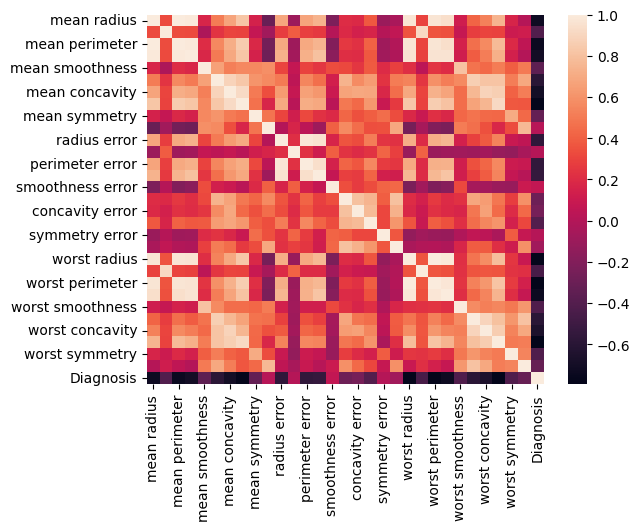

In [2]:
import seaborn as sns

sns.heatmap(df.corr())

In [3]:
X = data.data
y= data.target
X_train , X_test, y_train , y_test = train_test_split(X, y ,random_state=42, test_size = 0.3)


In [21]:
tree = DecisionTreeClassifier(criterion='entropy',max_depth=3,min_samples_split= 2)
tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

Note: Overfitting : -> High accuracy and training >> testing accuracy.

Overfitting decrases considerably by pruning trees
There are about 5 to 6 parameters through which we can use to control or decrease overfitting.

Underfitting : Lesser Accuracy values.




In [22]:
y_pred = tree.predict(X_test)
print("Testing Accuracy: ",accuracy_score(y_test,y_pred))
y_pred_train = tree.predict(X_train)
print("Training Accuracy: ",accuracy_score(y_train,y_pred_train))
'''
# at random state = 32
Testing  =92
Training = 97

At random state = 42
testing = 96(accuracy increased)
training = 97
'''

Testing Accuracy:  0.9649122807017544
Training Accuracy:  0.9798994974874372


'\n# at random state = 32\nTesting  =92\nTraining = 97\n\nAt random state = 42\ntesting = 96(accuracy increased)\ntraining = 97\n'

In [23]:
print("Report test",classification_report(y_test, y_pred, target_names= data.target_names))


Report test               precision    recall  f1-score   support

   malignant       0.97      0.94      0.95        63
      benign       0.96      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [9]:
print("Confusion Matrix: Test Data\n", confusion_matrix(y_test,y_pred))

Confusion Matrix: Test Data
 [[ 59   4]
 [  2 106]]


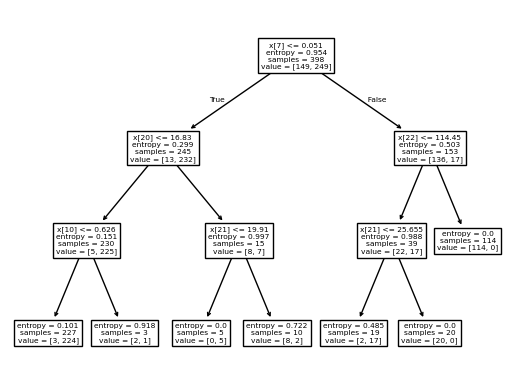

In [10]:
import matplotlib.pyplot as plt
plot_tree(tree)
plt.show()

**Ask about parameters and how do we read this graph.**





## Random Forest

This algorithm creates a collection of decision tress by randomizing data which reduces bias and overfitting.This is an ensemble learning model.

Randomizing reduces the number of samples on which model is trained -> And that is why overfitting is reduced -- generalization is introduced.

**Ensemble learning models** = techniques where multiple models (often called "weak learners") are combined together to make a single stronger, more accurate, and more robust model.

In [11]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=43)
random_forest.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=3, random_state=43)

In [12]:
y_pred = random_forest.predict(X_test)
print("Testing Accuracy: ",accuracy_score(y_test,y_pred))
y_pred_train =  random_forest.predict(X_train)
print("Training Accuracy: ",accuracy_score(y_train,y_pred_train))

Testing Accuracy:  0.9649122807017544
Training Accuracy:  0.9773869346733668


In [13]:
print("Classification Report",classification_report(y_test,y_pred,target_names=data.target_names))

Classification Report               precision    recall  f1-score   support

   malignant       0.97      0.94      0.95        63
      benign       0.96      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



In [14]:
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred))

Confusion Matrix
 [[ 59   4]
 [  2 106]]


## Support Vector Machines

Support Vector Machines classifies or regresses data by segregating data in a hyperplane by drawing a border or line.

The shape of the curve(line) depends on the kernel (linear, polynomial, etc) which separates the classes.

It has a soft margin which kind of contain misclassified datapoints.SVM 's goal is to find this margin

This margin is controlled by parameter -- C.


*   Larger C -> smaller margin -- Strict Separations
*   Smaller C -> Large margins --  Soft Separations

Use case : Sentiment analysis, image analysis,etc


Works best on linear and weakly separable data.

Sensitive to kernal (linear, polynomial, etc) which is being used.






In [15]:
from sklearn.svm import SVC
svm = SVC(
    kernel='poly'
)
svm.fit(X_train,y_train)

SVC(kernel='poly')

In [16]:
y_pred = svm.predict(X_test)
print("Testing Accuracy: ",accuracy_score(y_test,y_pred))
y_pred_train =  svm.predict(X_train)
print("Training Accuracy: ",accuracy_score(y_train,y_pred_train))

Testing Accuracy:  0.9415204678362573
Training Accuracy:  0.8944723618090452


In [17]:
print("Classification Report",classification_report(y_test,y_pred,target_names=data.target_names))

Classification Report               precision    recall  f1-score   support

   malignant       0.98      0.86      0.92        63
      benign       0.92      0.99      0.96       108

    accuracy                           0.94       171
   macro avg       0.95      0.92      0.94       171
weighted avg       0.94      0.94      0.94       171



##Naive Bayes

Naive Bayes considers that all the features are independent.

How this works?
* We calculate probability of each class

* Then probability of the features for each class.

* We combine the probability of desired features.

Use case: Spam detection, text analysis etc






In [18]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train,y_train)

GaussianNB()

In [19]:
y_pred = nb.predict(X_test)
print("Testing Accuracy: ",accuracy_score(y_test,y_pred))
y_pred_train =  nb.predict(X_train)
print("Training Accuracy: ",accuracy_score(y_train,y_pred_train))


Testing Accuracy:  0.9415204678362573
Training Accuracy:  0.9396984924623115


In [20]:
print("Classification Report",classification_report(y_test,y_pred,target_names=data.target_names))

Classification Report               precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        63
      benign       0.95      0.96      0.95       108

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171

